# [Computational Social Science] Project 4: Unsupervised Learning

**Hesham Jarmakani:**

**In Collaboration with Mohammed Mohammed & Marwa Abubakr**

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [1]:
#!pip install tensorflow 
#!pip install keras

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

2025-12-09 17:06:10.238004: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-09 17:06:10.239687: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-09 17:06:10.394999: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/srv/conda/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_v

In [3]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

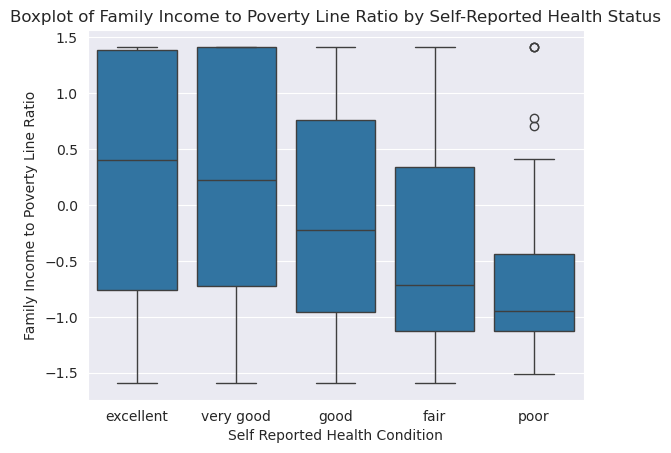

In [4]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

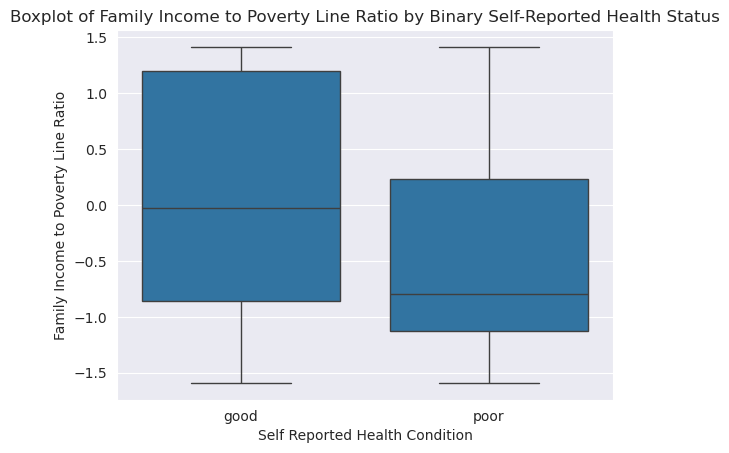

In [5]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

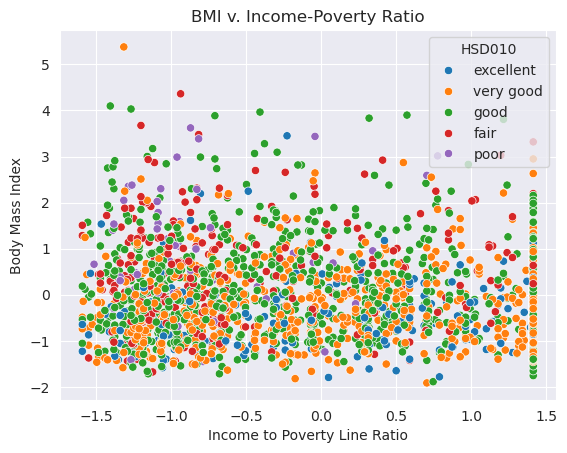

In [6]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [7]:
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA and Discuss Number of Components

In [8]:
# 1. Fit PCA with all components first, once graphed we will see how many components to choose.
pca_10 = PCA(n_components= 10)            
pca_10.fit(nhanes_scaled)

explained_var = pca_10.explained_variance_ratio_
cum_explained_var = explained_var.cumsum()

### Barplot of Components

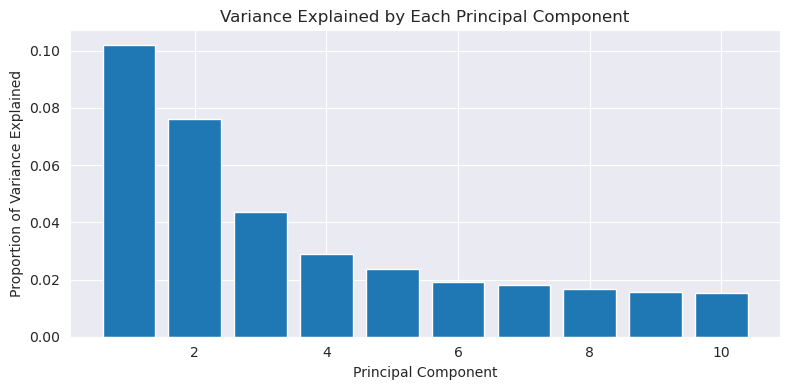

In [9]:
# 2. barplot of variance explained by each component
plt.figure(figsize=(8,4))
plt.bar(range(1, len(explained_var)+1), explained_var)
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Variance Explained by Each Principal Component")
plt.tight_layout()
plt.show()

### How many components will you use to fit a supervised learning model?

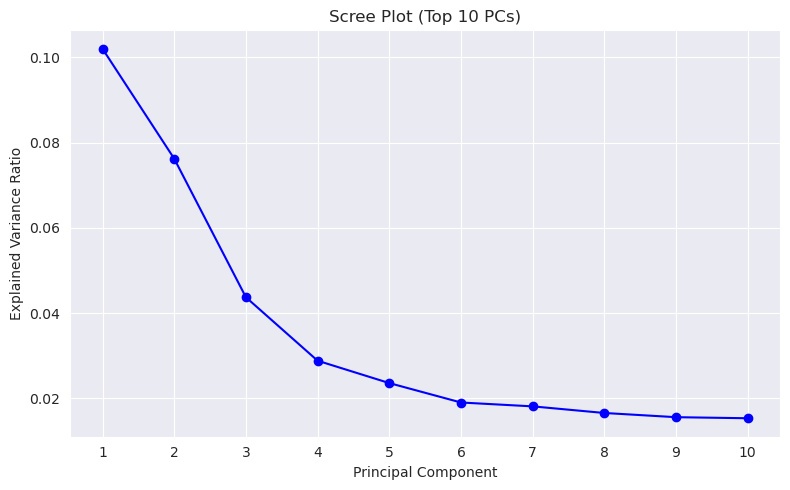

In [10]:
#scree plot for top 10 components to determine how many components to keep 
explained_variance = pca_10.explained_variance_ratio_  # from PCA(n_components=10)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
plt.title('Scree Plot (Top 10 PCs)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance) + 1))
plt.tight_layout()
plt.show()


From the scree plot, the elbow appears to be around the third and fourth principal componenets. We notice a big drop in explained variance from the third to the fourth, so to make our model simple I choose three compenents. 

### 2D Scatterplot of the first two components

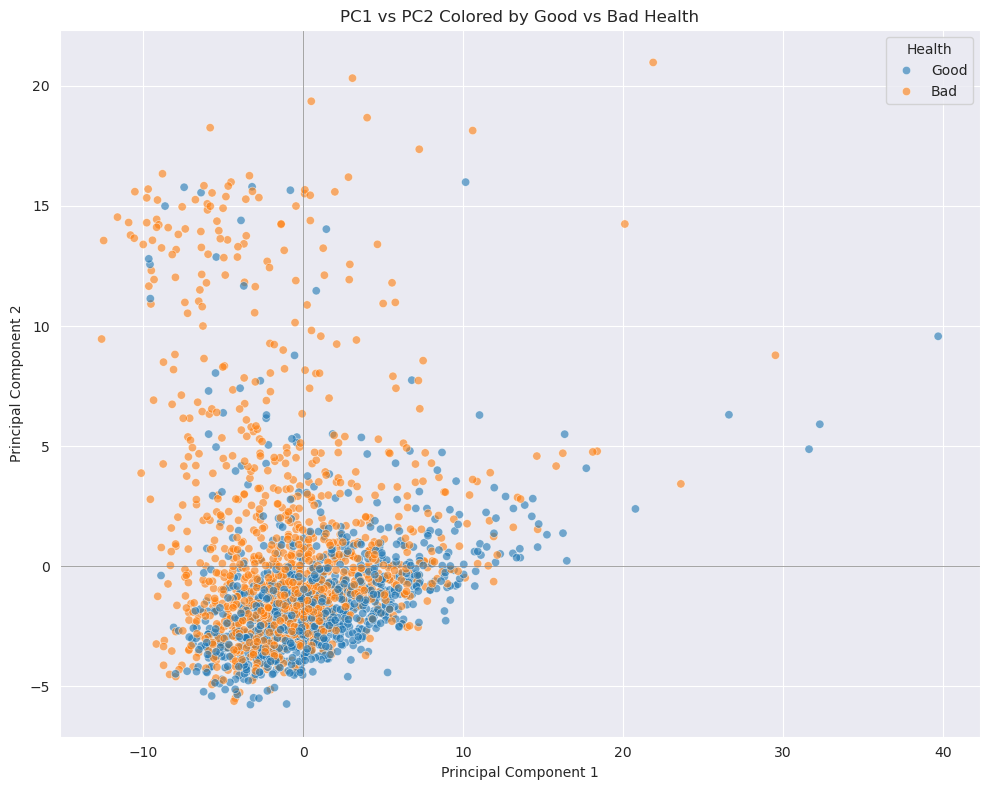

In [11]:
#2d scatter plot of the first two components, colored by good vs bad health 
# 1. PCA on predictors 
pca_2 = PCA(n_components=2)
nhanes_pca_2 = pca_2.fit_transform(nhanes_scaled)

# 2. Make a binary outcome from HSD010 (example rule: 1–2 = good, 3–5 = bad)
health_bin = hsd010.replace({1: "Good", 2: "Good", 3: "Bad", 4: "Bad", 5: "Bad"})

# 3. Put PCs + outcome in a DataFrame
pc_df = pd.DataFrame({
    "PC1": nhanes_pca_2[:, 0],
    "PC2": nhanes_pca_2[:, 1],
    "Health": health_bin
})

# 4. Plot PC1 vs PC2, colored by good vs bad health
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="Health", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PC1 vs PC2 Colored by Good vs Bad Health")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()


From our scatterplot of the first two components, we see that the first two components clearly capture structure in the predictors, but the "Good" and "Bad" health observations are heavily mixed. This shows us that PCA by itself does not cleanly separate people by health status. I notice a slight pattern where "Bad" Health observations appear more often in the upper left region of the scatter plot. This suggests that certain combinations of predictors in that area are associated with self reported health, but there is  still substantial overlapping.  


## K-Means

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

I chose K means clustering, since it groups data points into k clusters, so that all points in the same clusters are as similar as possible and that points in different clusters are as different as possible. It does this by repeatedly assigning points to the nearest centroid, and updating those centroids to be the mean of their assigned points. This helps us find groups of similar observations in unlabeled data, to help discover patterns across observations. 

### Cluster nhanes

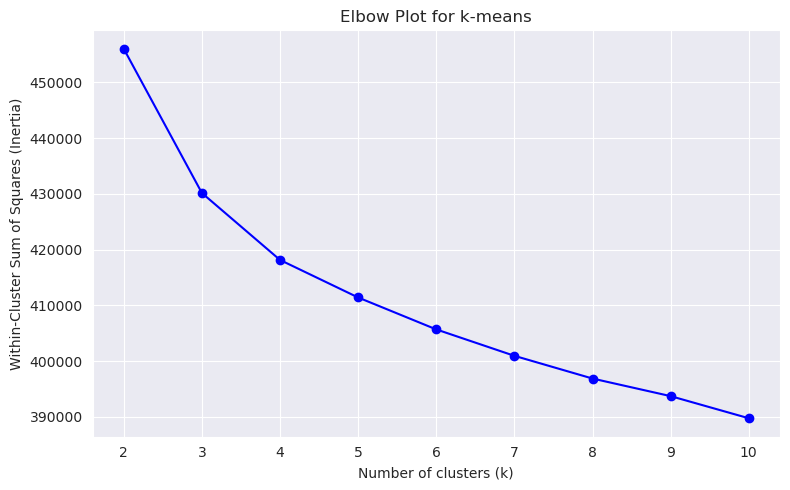

In [12]:
## K means clustering on nhanes data 

X = nhanes_scaled  

# --- Elbow method to choose k ---
inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.title('Elbow Plot for k-means')
plt.xticks(k_values)
plt.tight_layout()
plt.show()


In [13]:
k_opt = 4  # set to your chosen k based on the elbow plot

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

nhanes_clusters = nhanes_scaled.copy()
nhanes_clusters['cluster'] = clusters


### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

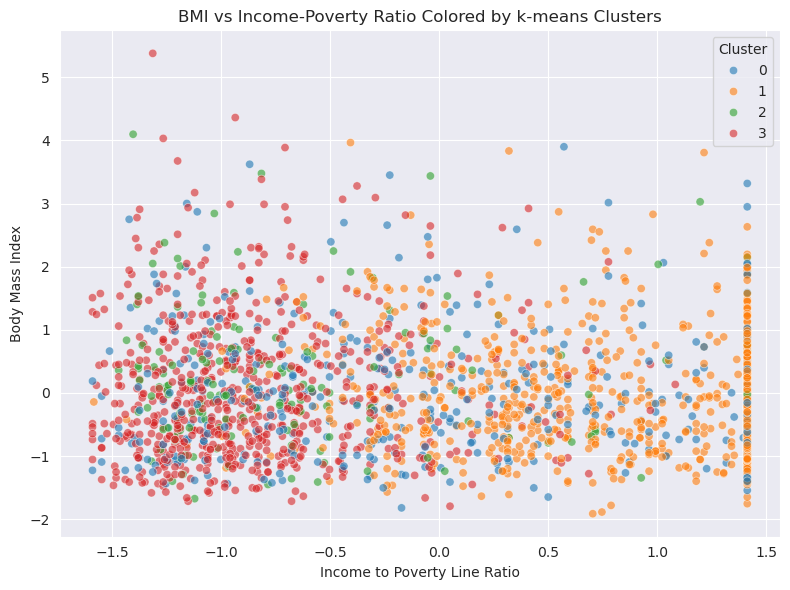

In [15]:

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=nhanes_clusters,
    x='INDFMPIR',
    y='BMXBMI',
    hue='cluster',
    palette='tab10',
    alpha=0.6
)
plt.xlabel('Income to Poverty Line Ratio')
plt.ylabel('Body Mass Index')
plt.title('BMI vs Income-Poverty Ratio Colored by k-means Clusters')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


The clusters mainly separate along the income to poverty ratio axis. Also, BMI varies within each cluster and overlaps a lot across clusters. This suggest that income may be more strongly aligned with the k-means structure than BMI is. 

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

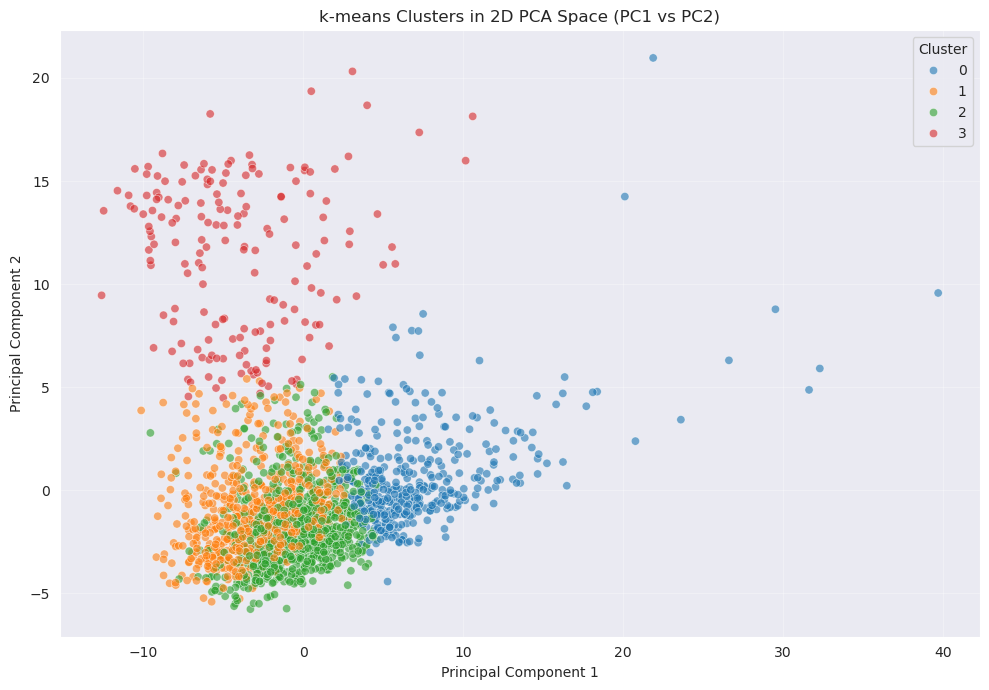

In [16]:
# kmeans on PCA scores instead of original features
# 1. PCA with 3 components
pca = PCA(n_components=3, random_state=42)
X_pca3 = pca.fit_transform(nhanes_scaled)   # shape: (n_samples, 3)

# 2. k-means on the 2-D PCA scores K= 4
k_opt = 4
kmeans_pca3 = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters_pca3 = kmeans_pca3.fit_predict(X_pca3)

# 3. DataFrame for plotting first two PCs + cluster labels
pca_cluster_df = pd.DataFrame({
    'PC1': X_pca3[:, 0],
    'PC2': X_pca3[:, 1],
    'cluster': clusters_pca3
})

# 4. Plot clusters on the 2D PCA scatterplot (PC1 vs PC2)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_cluster_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.6
)
plt.title('k-means Clusters in 2D PCA Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


By running k-means on the PCA components, each color in the plot represents a cluster of respondents with similar predictor profiles. This shows that k-means clustering can reveal distinct subgroups in the compressed PCA space and makes the underlying structure of the data easier to see and interpret.

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features 3.5 

In [17]:
# partition data
# -----------
y = hsd010.replace({1:0, 2:1, 3:2, 4:3, 5:4})   # convert to 0–4 for NN
X = nhanes_scaled                                 # features only (already numeric)

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

In [18]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical

num_classes = 5
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

In [19]:
# create neural network model
# -----------
model = Sequential()

model.add(Dense(64, input_dim= X_train.shape[1], kernel_initializer= 'he_uniform', activation= 'relu'))

model.add(Dense(32, kernel_initializer= 'he_uniform', activation= 'relu'))

model.add(Dense(5, activation='softmax'))

## Add any additional layers you wish here

model.compile(loss= 'categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

Epoch 1/20


/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-09 17:07:47.320349: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3876 - loss: 1.4963 - val_accuracy: 0.4089 - val_loss: 1.3955
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4994 - loss: 1.2139 - val_accuracy: 0.4360 - val_loss: 1.3397
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5665 - loss: 1.0824 - val_accuracy: 0.4322 - val_loss: 1.3095
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6085 - loss: 0.9722 - val_accuracy: 0.4399 - val_loss: 1.2838
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.8781 - val_accuracy: 0.4341 - val_loss: 1.2675
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7080 - loss: 0.7943 - val_accuracy: 0.4535 - val_loss: 1.2617
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7442 - loss: 0.7079 - val_accuracy: 0.4574 - val_loss: 1.2649
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7978 - loss: 0.6296 - val_accuracy: 0.4671 - val_loss: 1.2750
Epo

### Neural Network on Principal Components

In [20]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(nhanes_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.25, random_state=10
)

num_classes = 5
y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test,  num_classes)

model = Sequential()

model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20, batch_size=32, verbose=1
)

Epoch 1/20


/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1764 - loss: 2.0999 - val_accuracy: 0.3101 - val_loss: 1.5911
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3727 - loss: 1.4676 - val_accuracy: 0.4109 - val_loss: 1.3942
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4335 - loss: 1.3544 - val_accuracy: 0.4399 - val_loss: 1.3416
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4496 - loss: 1.3176 - val_accuracy: 0.4360 - val_loss: 1.3187
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4651 - loss: 1.2937 - val_accuracy: 0.4477 - val_loss: 1.3011
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4574 - loss: 1.2796 - val_accuracy: 0.4457 - val_loss: 1.2854
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4677 - loss: 1.2670 - val_accuracy: 0.4457 - val_loss: 1.2785
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4703 - loss: 1.2554 - val_accuracy: 0.4496 - val_loss: 1.2670
Epo

### Neural Network on Principal Components + Cluster Membership

In [21]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(nhanes_scaled)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)  

cluster_encoded = pd.get_dummies(clusters, prefix='cluster').values
X_nn = np.hstack([X_pca, cluster_encoded])

y = hsd010.replace({1:0, 2:1, 3:2, 4:3, 5:4})  
y_train, y_test, X_train, X_test = train_test_split(y, X_nn, test_size=0.25, random_state=10)

y_train = to_categorical(y_train, num_classes=5)
y_test  = to_categorical(y_test, num_classes=5)

model = Sequential()
model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

Epoch 1/20


/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2681 - loss: 1.7174 - val_accuracy: 0.3895 - val_loss: 1.5117
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4199 - loss: 1.4252 - val_accuracy: 0.4302 - val_loss: 1.3737
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4554 - loss: 1.3485 - val_accuracy: 0.4205 - val_loss: 1.3169
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4522 - loss: 1.3103 - val_accuracy: 0.4399 - val_loss: 1.2867
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4722 - loss: 1.2817 - val_accuracy: 0.4457 - val_loss: 1.2678
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4716 - loss: 1.2634 - val_accuracy: 0.4302 - val_loss: 1.2544
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4651 - loss: 1.2490 - val_accuracy: 0.4457 - val_loss: 1.2450
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4767 - loss: 1.2383 - val_accuracy: 0.4360 - val_loss: 1.2397
Epo

After using PCA (5 components) and adding 4 cluster dummy variables from K means, the neural network achieves approximately 47% training accuracy and 44% validation accuracy. The close train & validation performance suggests that our neural network has limited overfitting, but the overall accuracy is moderate. This suggest that the unsupervised features capture some signal but do not fuly explain the variation in the outcome.  

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

PCA's primary goal is to reduce the number of features while simulataneously keeping as much of the overall variation in the dataset as possible. To do so, PCA searches for principal components, which are linear combinations of the original variables. The first component often explains most of the variance, and the second one explains the second most and so on and so forth (however, this decreases as you add more components). The result is a transformation of the data into a new coordinate system defined by these components, along with information on how much variance each component accounts for.

In contrast, clustering focuses on grouping observations into distinct clusters such that points within the same cluster are more similar to one another than to those in different clusters. It uses a similarity measure to seperate the data into groups and tries to minimize the within-cluster distances and maximize the between-cluster distances. The output is a cluster assignment for each observation. 

In our case, PCA projected each observation into a two-dimensional space. Afterward, K-means clustering grouped the observations into four clusters based on their similarities.

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

I did not observe a significant performance improvement from adding the cluster indicators to the PCA features. The neural network’s training and validation accuracy remained around 45% to 47%. This may be because the 5 PCA components already included most of the structure that k-means discovered, so the cluster dummies added little additional information.
Alternatively, there is the possibility that the relationship between the clusters and the outcome is weak, so the network cannot use those cluster labels to improve predictions by a lot.

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

Unsupervised methods are valuable because they help clean and organize input data before training a predictive model. They assist with dimensionality reduction by compressing high levels of correlated variables into a smaller set of important informative features. This can speed up training and also reduce the risk of overfitting. In addition, clustering can reveal hidden groups/trends within the data. By including cluster labels as features, a supervised model can learn different patterns across groups if their behaviors differ.
Unsupervised techniques also support data cleaning and wide-scale labeling efforts. They can help detect major outliers that might otherwise introduce errors during analysis. Additionally, they can guide researchers on which observations to label first, which is incredibly important when obtaining labeled data is costly/time-consuming. 
Overall, unsupervised methods can help transform large, complex datasets into more compact and structured inputs that can improve the performance of supervised models.